# Southern Indiana Housing and Public School Analysis 
## Part 1

This project analyzes housing sales data from multiple resources (Redfin and Realtor.com Data Centers) along with the results of the ILEARN standardized test for school corporations in Clark and Floyd counties located in Southern Indian. The goal of this project is to anticipate housing prices within the better school districts within those counties in anticipation of a potential move for my family.



In [ ]:
#Import necessary libraries and such for project. And some extra stuff, just in case.
import pandas as pd
import matplotlib
from pandas import DataFrame
import matplotlib.pyplot as plt
import numpy as np
import datetime



Now I will read in data I sourced from Redfin's Data Center - it includes data for all of the United State

#### Housing Data by County for the state of Indiana

In [163]:
# Reading in the mother file with all housing data by county

housing_data= pd.read_csv('Data_Sources\county_market_tracker_clean.zip')
housing_data.head()

,period_begin,period_end,table_id,region,state,state_code,property_type,property_type_id,median_sale_price,median_list_price,median_ppsf,median_ppsf_yoy,median_list_ppsf,median_list_ppsf_yoy,inventory,inventory_yoy,sold_above_list,parent_metro_region,parent_metro_region_metro_code,last_updated
0,4/1/2015,4/30/2015,2550,"Bradley County, TN",Tennessee,TN,Condo/Co-op,3,199900.0,NaN,137.957212,NaN,NaN,NaN,3.0,NaN,0.000000,"Cleveland, TN",17420.0,2/10/2025 14:21
1,2/1/2014,2/28/2014,1958,"Dutchess County, NY",New York,NY,Townhouse,13,190250.0,269500.0,133.055161,-0.017109,127.048023,0.062799,21.0,-0.125000,0.000000,"Poughkeepsie, NY",39100.0,2/10/2025 14:21
2,6/1/2023,6/30/2023,1643,"Holt County, MO",Missouri,MO,Single Family Residential,6,75500.0,229500.0,40.810811,-0.724764,120.578231,0.525863,13.0,1.166667,0.000000,Missouri nonmetropolitan area,NaN,2/10/2025 14:21
3,3/1/2015,3/31/2015,1518,"Adams County, MS",Mississippi,MS,All Residential,-1,94900.0,160750.0,70.059310,-0.224828,81.662621,0.217752,57.0,-0.123077,0.181818,"Natchez, MS",35020.0,2/10/2025 14:21
4,2/1/2016,2/29/2016,806,"Washington County, IL",Illinois,IL,Single Family Residential,6,49000.0,76500.0,32.236842,-0.121009,67.222597,-0.260068,57.0,0.212766,0.400000,Illinois nonmetropolitan area,NaN,2/10/2025 14:21


I can see from looking at the first five rows that the dataset I found has housing data from across the United States going back at leas 11 years. That's more than I need, but I want to get a better idea of what the whole dataframe looks like. Let me see the shape and datatypes I'll be working with. 

In [164]:
# What are the columns? I thought I saw pricing per sqft. I need to list all the column names.
# Displaying the size and data types of our data
hdata_shape = housing_data.shape
print(f'The DataFrame has {hdata_shape[0]} rows and {hdata_shape[1]} columns! \n')
print(housing_data.info(20)) 

The DataFrame has 1048575 rows and 20 columns! 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 20 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   period_begin                    1048575 non-null  object 
 1   period_end                      1048575 non-null  object 
 2   table_id                        1048575 non-null  int64  
 3   region                          1048575 non-null  object 
 4   state                           1048575 non-null  object 
 5   state_code                      1048575 non-null  object 
 6   property_type                   1048575 non-null  object 
 7   property_type_id                1048575 non-null  int64  
 8   median_sale_price               1047819 non-null  float64
 9   median_list_price               963668 non-null   float64
 10  median_ppsf                     1037705 non-null  float64
 11  median_ppsf_yo

I'm not interested in year over year data because, for this project, I'm not interested in how the pricing is trending in those counties. I just want a recent snapshot. I'll also have to control for property type since we're only interested in purchasing a single family home. The columns I'll keep are: period_begin, period_end, region (this is the county in this data), state, property_type, median_sale_price, and median_ppsf. 

In [165]:
# drop columns now that I know which columns I want
housing_data_clean = housing_data[['period_begin', 'period_end', 'region', 'state','property_type', 'median_sale_price', 'median_list_price', 'median_ppsf']]
housing_data_clean


,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
0,4/1/2015,4/30/2015,"Bradley County, TN",Tennessee,Condo/Co-op,199900.0,NaN,137.957212
1,2/1/2014,2/28/2014,"Dutchess County, NY",New York,Townhouse,190250.0,269500.0,133.055161
2,6/1/2023,6/30/2023,"Holt County, MO",Missouri,Single Family Residential,75500.0,229500.0,40.810811
3,3/1/2015,3/31/2015,"Adams County, MS",Mississippi,All Residential,94900.0,160750.0,70.059310
4,2/1/2016,2/29/2016,"Washington County, IL",Illinois,Single Family Residential,49000.0,76500.0,32.236842
...,...,...,...,...,...,...,...,...
1048570,2/1/2015,2/28/2015,"Apache County, AZ",Arizona,Single Family Residential,151000.0,NaN,91.972077
1048571,1/1/2021,1/31/2021,"Forsyth County, NC",North Carolina,All Residential,209000.0,225000.0,116.748840
1048572,6/1/2022,6/30/2022,"Boone County, WV",West Virginia,Condo/Co-op,35000.0,NaN,7.000000
1048573,4/1/2021,4/30/2021,"Livingston Parish, LA",Louisiana,All Residential,212000.0,219900.0,106.772422


In [228]:
#clean the merged data by narrowing down property types
cleaned_cf = housing_data_clean.loc[housing_data_clean["property_type"] == "Single Family Residential"]

#display the df to verify the correct rows have been removed
display(cleaned_cf)

,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
2,6/1/2023,6/30/2023,"Holt County, MO",Missouri,Single Family Residential,75500.0,229500.0,40.810811
4,2/1/2016,2/29/2016,"Washington County, IL",Illinois,Single Family Residential,49000.0,76500.0,32.236842
16,1/1/2023,1/31/2023,"Plymouth County, IA",Iowa,Single Family Residential,230000.0,319750.0,114.113650
17,1/1/2025,1/31/2025,"Hendricks County, IN",Indiana,Single Family Residential,330000.0,347450.0,152.453591
22,5/1/2024,5/31/2024,"Madison County, FL",Florida,Single Family Residential,256600.0,266450.0,170.274970
...,...,...,...,...,...,...,...,...
1048558,5/1/2012,5/31/2012,"McLean County, IL",Illinois,Single Family Residential,72650.0,114900.0,44.549816
1048560,1/1/2013,1/31/2013,"Northampton County, NC",North Carolina,Single Family Residential,22500.0,49900.0,15.000000
1048561,8/1/2021,8/31/2021,"Hickman County, TN",Tennessee,Single Family Residential,205000.0,259900.0,138.714514
1048566,10/1/2019,10/31/2019,"Fayette County, KY",Kentucky,Single Family Residential,223500.0,219500.0,117.670131


Next I'll remove all the rows that do not have Indiana as a state by focusing on specific counties in Indiana that I want to analyze. I'll put these into three separate dataframes and then merge them.

In [229]:
#removes rows that do not contai

housing_data_clark = cleaned_cf.loc[cleaned_cf["region"] == "Clark County, IN"]
housing_data_floyd = cleaned_cf.loc[cleaned_cf["region"]== "Floyd County, IN"]

display(housing_data_clark, housing_data_floyd)

,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
1796,12/1/2014,12/31/2014,"Clark County, IN",Indiana,Single Family Residential,129400.0,139950.0,80.013918
22387,12/1/2013,12/31/2013,"Clark County, IN",Indiana,Single Family Residential,122000.0,124900.0,79.416283
27627,5/1/2013,5/31/2013,"Clark County, IN",Indiana,Single Family Residential,112000.0,123900.0,73.339400
27672,5/1/2016,5/31/2016,"Clark County, IN",Indiana,Single Family Residential,135900.0,139900.0,82.405345
38531,10/1/2017,10/31/2017,"Clark County, IN",Indiana,Single Family Residential,160784.0,150000.0,93.334844
...,...,...,...,...,...,...,...,...
1024781,12/1/2016,12/31/2016,"Clark County, IN",Indiana,Single Family Residential,138500.0,139900.0,90.804355
1029177,9/1/2023,9/30/2023,"Clark County, IN",Indiana,Single Family Residential,246900.0,250000.0,156.583037
1035975,2/1/2022,2/28/2022,"Clark County, IN",Indiana,Single Family Residential,224000.0,239950.0,148.619957
1036652,11/1/2024,11/30/2024,"Clark County, IN",Indiana,Single Family Residential,260000.0,244900.0,171.232980


,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
24,1/1/2014,1/31/2014,"Floyd County, IN",Indiana,Single Family Residential,108500.0,139900.0,58.016878
18401,10/1/2012,10/31/2012,"Floyd County, IN",Indiana,Single Family Residential,140450.0,123900.0,71.110239
18419,3/1/2014,3/31/2014,"Floyd County, IN",Indiana,Single Family Residential,114000.0,139900.0,72.264351
56998,8/1/2013,8/31/2013,"Floyd County, IN",Indiana,Single Family Residential,130125.0,159900.0,73.380902
57840,8/1/2021,8/31/2021,"Floyd County, IN",Indiana,Single Family Residential,224900.0,210000.0,124.304322
...,...,...,...,...,...,...,...,...
982168,3/1/2013,3/31/2013,"Floyd County, IN",Indiana,Single Family Residential,115000.0,149900.0,69.544365
988376,2/1/2024,2/29/2024,"Floyd County, IN",Indiana,Single Family Residential,275000.0,302400.0,148.026316
996063,7/1/2021,7/31/2021,"Floyd County, IN",Indiana,Single Family Residential,247500.0,215000.0,124.674620
1017426,3/1/2012,3/31/2012,"Floyd County, IN",Indiana,Single Family Residential,116500.0,123375.0,61.635220


In [230]:
#join the two dataframes back together
clark_floyd = housing_data_clark.merge(housing_data_floyd, how = 'outer')
clark_floyd

#drop any rows with NaN values
clark_floyd = clark_floyd.dropna()

# Remove State Column - that information is included in the Region column
clark_floyd = clark_floyd.drop(columns=['state'])

#make a copy of the data
clark_floyd.copy()

,period_begin,period_end,region,property_type,median_sale_price,median_list_price,median_ppsf
0,1/1/2012,1/31/2012,"Clark County, IN",Single Family Residential,121750.0,141400.0,65.195190
1,1/1/2012,1/31/2012,"Floyd County, IN",Single Family Residential,140000.0,114950.0,69.771352
2,1/1/2013,1/31/2013,"Clark County, IN",Single Family Residential,116000.0,120000.0,76.371585
3,1/1/2013,1/31/2013,"Floyd County, IN",Single Family Residential,87500.0,162400.0,66.601837
4,1/1/2014,1/31/2014,"Clark County, IN",Single Family Residential,127950.0,136900.0,73.727365
...,...,...,...,...,...,...,...
271,9/1/2022,9/30/2022,"Floyd County, IN",Single Family Residential,225000.0,234900.0,139.863548
272,9/1/2023,9/30/2023,"Clark County, IN",Single Family Residential,246900.0,250000.0,156.583037
273,9/1/2023,9/30/2023,"Floyd County, IN",Single Family Residential,289000.0,279950.0,151.166514
274,9/1/2024,9/30/2024,"Clark County, IN",Single Family Residential,249900.0,260000.0,164.021164


In [231]:
#checking for any NaN values in the median sales column
check_nan_sale = clark_floyd['median_sale_price'].isnull().values.any()

print(check_nan_sale)

False


In [232]:
# checking for any NaN values in the median list price
check_nan_ppsf= clark_floyd['median_list_price'].isnull().values.any()

#print the results
print(check_nan_ppsf)

False


In [233]:
# checking for any NaN values in the price per square foot
check_nan_list= clark_floyd['median_ppsf'].isnull().values.any()

#print the results
print(check_nan_list)

False


There are no NaN values in this selection of data. 

In [166]:
#removes rows that do not contai

housing_data_clark = housing_data_clean.loc[housing_data_clean["region"] == "Clark County, IN"]
housing_data_floyd = housing_data_clean.loc[housing_data_clean["region"]== "Floyd County, IN"]

display(housing_data_clark, housing_data_floyd)

,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
643,1/1/2016,1/31/2016,"Clark County, IN",Indiana,Condo/Co-op,95950.0,NaN,77.715124
1796,12/1/2014,12/31/2014,"Clark County, IN",Indiana,Single Family Residential,129400.0,139950.0,80.013918
1842,12/1/2015,12/31/2015,"Clark County, IN",Indiana,Condo/Co-op,39000.0,139900.0,30.468750
4393,11/1/2016,11/30/2016,"Clark County, IN",Indiana,All Residential,137350.0,150000.0,79.753239
7871,12/1/2012,12/31/2012,"Clark County, IN",Indiana,All Residential,122000.0,120000.0,71.851226
...,...,...,...,...,...,...,...,...
1036652,11/1/2024,11/30/2024,"Clark County, IN",Indiana,Single Family Residential,260000.0,244900.0,171.232980
1040135,2/1/2021,2/28/2021,"Clark County, IN",Indiana,Condo/Co-op,246750.0,249900.0,154.681779
1040502,7/1/2024,7/31/2024,"Clark County, IN",Indiana,Condo/Co-op,169500.0,253245.0,150.223214
1046036,4/1/2018,4/30/2018,"Clark County, IN",Indiana,Single Family Residential,154000.0,169900.0,97.244733


,period_begin,period_end,region,state,property_type,median_sale_price,median_list_price,median_ppsf
24,1/1/2014,1/31/2014,"Floyd County, IN",Indiana,Single Family Residential,108500.0,139900.0,58.016878
2800,8/1/2017,8/31/2017,"Floyd County, IN",Indiana,All Residential,182000.0,164500.0,91.635338
6488,9/1/2017,9/30/2017,"Floyd County, IN",Indiana,All Residential,160253.0,149450.0,82.346697
6742,12/1/2024,12/31/2024,"Floyd County, IN",Indiana,Multi-Family (2-4 Unit),195000.0,252450.0,150.000000
7526,4/1/2017,4/30/2017,"Floyd County, IN",Indiana,Condo/Co-op,81900.0,179950.0,68.136439
...,...,...,...,...,...,...,...,...
1040934,9/1/2020,9/30/2020,"Floyd County, IN",Indiana,All Residential,200250.0,199900.0,112.685115
1041413,4/1/2024,4/30/2024,"Floyd County, IN",Indiana,All Residential,300000.0,279900.0,150.660478
1042398,12/1/2020,12/31/2020,"Floyd County, IN",Indiana,All Residential,203000.0,185000.0,113.318379
1045086,5/1/2015,5/31/2015,"Floyd County, IN",Indiana,All Residential,163000.0,149900.0,82.408342


I now have the housing data in two separate dataframes. I'll merge these into one. An outer join should be sufficient since there won't be anything they have in common besides Indiana. 

In [167]:
#join the Three cleaned datasets together


clark_floyd = housing_data_clark.merge(housing_data_floyd, how = 'outer')
clark_floyd

#drop any rows with NaN values
clark_floyd = clark_floyd.dropna()

# Remove State Column - that information is included in the Region column
clark_floyd = clark_floyd.drop(columns=['state'])

#make a copy of the data
clark_floyd.copy()

,period_begin,period_end,region,property_type,median_sale_price,median_list_price,median_ppsf
0,1/1/2012,1/31/2012,"Clark County, IN",All Residential,124250.0,141400.0,66.903633
1,1/1/2012,1/31/2012,"Clark County, IN",Single Family Residential,121750.0,141400.0,65.195190
2,1/1/2012,1/31/2012,"Floyd County, IN",All Residential,140000.0,114950.0,69.771352
3,1/1/2012,1/31/2012,"Floyd County, IN",Single Family Residential,140000.0,114950.0,69.771352
4,1/1/2013,1/31/2013,"Clark County, IN",All Residential,116000.0,120000.0,76.371585
...,...,...,...,...,...,...,...
837,9/1/2024,9/30/2024,"Clark County, IN",Single Family Residential,249900.0,260000.0,164.021164
838,9/1/2024,9/30/2024,"Clark County, IN",Townhouse,219900.0,260000.0,167.606707
839,9/1/2024,9/30/2024,"Floyd County, IN",All Residential,231250.0,257450.0,148.266423
840,9/1/2024,9/30/2024,"Floyd County, IN",Condo/Co-op,155900.0,257450.0,134.355275


Now I know I have all the data I want so I'm going to clean up the column headers.

In [169]:
"""
Cleans and processes the Bartholomew, Clark, and Floyd County Housing DataFrame.

    This function performs the following operations on the input DataFrame:
    1. Cleans column names (capitalizes and removes underscores).

    Parameters:
        bart_clark_floyd (pandas.DataFrame): The input housing dataset.

    Returns:
        pandas.DataFrame: The cleaned and processed DataFrame.

    Example:
        >>> clean_kick_starter = clean_ks(bart_clark_floyd)\"
"""
# function       
def clean_hd (cleaned_cf) -> pd.DataFrame:

    # Clean column names
    cleaned_cf.columns =  cleaned_cf.columns.str.title()
    cleaned_cf.columns =  cleaned_cf.columns.str.strip().str.replace('_', ' ')

    return cleaned_cf

final_cf = clean_hd(cleaned_cf)

display(final_cf)


,Period Begin,Period End,Region,Property Type,Median Sale Price,Median List Price,Median Ppsf
1,1/1/2012,1/31/2012,"Clark County, IN",Single Family Residential,121750.0,141400.0,65.195190
3,1/1/2012,1/31/2012,"Floyd County, IN",Single Family Residential,140000.0,114950.0,69.771352
6,1/1/2013,1/31/2013,"Clark County, IN",Single Family Residential,116000.0,120000.0,76.371585
9,1/1/2013,1/31/2013,"Floyd County, IN",Single Family Residential,87500.0,162400.0,66.601837
12,1/1/2014,1/31/2014,"Clark County, IN",Single Family Residential,127950.0,136900.0,73.727365
...,...,...,...,...,...,...,...
830,9/1/2022,9/30/2022,"Floyd County, IN",Single Family Residential,225000.0,234900.0,139.863548
832,9/1/2023,9/30/2023,"Clark County, IN",Single Family Residential,246900.0,250000.0,156.583037
834,9/1/2023,9/30/2023,"Floyd County, IN",Single Family Residential,289000.0,279950.0,151.166514
837,9/1/2024,9/30/2024,"Clark County, IN",Single Family Residential,249900.0,260000.0,164.021164


In [170]:
#checking datatypes before I move on 
final_cf.dtypes

Period Begin          object
Period End            object
Region                object
Property Type         object
Median Sale Price    float64
Median List Price    float64
Median Ppsf          float64
dtype: object

There's sales data going all the way back to 2012. That will NOT be an accurate snapshot for current housing prices (thanks, COVID). Let's pull the last rolling 12 months. Since Period Begin and Period End are objects, I will need to change them to datetime datatypes so the computer will recognize them as timestamps. 

In [171]:

#it's an object, not datetime

#making a copy to avoid the SettingwithCopyWarning
final_cfcopy = final_cf.copy()


#change to datetime
final_cfcopy['Period Begin'] = pd.to_datetime(final_cfcopy['Period Begin'], format='%m/%d/%Y')

#adjust Period End to datetime 
final_cfcopy['Period End'] = pd.to_datetime(final_cfcopy['Period End'], format='%m/%d/%Y')

final_cfcopy


,Period Begin,Period End,Region,Property Type,Median Sale Price,Median List Price,Median Ppsf
1,2012-01-01,2012-01-31,"Clark County, IN",Single Family Residential,121750.0,141400.0,65.195190
3,2012-01-01,2012-01-31,"Floyd County, IN",Single Family Residential,140000.0,114950.0,69.771352
6,2013-01-01,2013-01-31,"Clark County, IN",Single Family Residential,116000.0,120000.0,76.371585
9,2013-01-01,2013-01-31,"Floyd County, IN",Single Family Residential,87500.0,162400.0,66.601837
12,2014-01-01,2014-01-31,"Clark County, IN",Single Family Residential,127950.0,136900.0,73.727365
...,...,...,...,...,...,...,...
830,2022-09-01,2022-09-30,"Floyd County, IN",Single Family Residential,225000.0,234900.0,139.863548
832,2023-09-01,2023-09-30,"Clark County, IN",Single Family Residential,246900.0,250000.0,156.583037
834,2023-09-01,2023-09-30,"Floyd County, IN",Single Family Residential,289000.0,279950.0,151.166514
837,2024-09-01,2024-09-30,"Clark County, IN",Single Family Residential,249900.0,260000.0,164.021164


In [172]:
isinstance(final_cfcopy,pd.DataFrame)

True

In [173]:
# Filter for the last rolling 13 months (anything after February 1, 2024)
filtered_cf = final_cfcopy.loc[(final_cfcopy['Period Begin'] >= '2024-02-01')]   

filtered_cf

,Period Begin,Period End,Region,Property Type,Median Sale Price,Median List Price,Median Ppsf
68,2025-01-01,2025-01-31,"Clark County, IN",Single Family Residential,250000.0,274900.0,145.509943
70,2025-01-01,2025-01-31,"Floyd County, IN",Single Family Residential,253900.0,290000.0,137.500000
141,2024-10-01,2024-10-31,"Floyd County, IN",Single Family Residential,235000.0,274900.0,155.259823
209,2024-11-01,2024-11-30,"Clark County, IN",Single Family Residential,260000.0,244900.0,171.232980
212,2024-11-01,2024-11-30,"Floyd County, IN",Single Family Residential,286500.0,269000.0,154.476351
281,2024-12-01,2024-12-31,"Clark County, IN",Single Family Residential,234945.0,262990.0,155.327776
285,2024-12-01,2024-12-31,"Floyd County, IN",Single Family Residential,301750.0,252450.0,148.990538
349,2024-02-01,2024-02-29,"Clark County, IN",Single Family Residential,252000.0,248500.0,160.736976
353,2024-02-01,2024-02-29,"Floyd County, IN",Single Family Residential,275000.0,302400.0,148.026316
415,2024-03-01,2024-03-31,"Clark County, IN",Single Family Residential,250000.0,263500.0,165.925455


In [174]:
#find average sale price for each county for past 12 months
average_saleprice = filtered_cf.groupby('Region')['Median Sale Price'].mean()
average_saleprice = pd.DataFrame(average_saleprice)
display(average_saleprice)

,Median Sale Price
Region,
"Clark County, IN",255938.5
"Floyd County, IN",278450.0


In [175]:
#barchart showing price per square foot
# # fig = px.bar(filtered_cf, x='Period Begin', y='Median Ppsf', color='Region', barmode='group',
             #title='Median Price per Square Foot from February 2024 to January 2025',
             #labels={'Median Ppsf': 'Median Price Per Square Foot ($)', 'Date': 'Period Begin'},
             #height=400)

# fig.show()

In [176]:
#find average sale price for each county for past 12 months
average_ppsf = filtered_cf.groupby('Region')['Median Ppsf'].mean()
average_ppsf = pd.DataFrame(average_ppsf)
display(average_ppsf)

,Median Ppsf
Region,
"Clark County, IN",163.120663
"Floyd County, IN",151.948779


# Southern Indiana Housing and Public School Analysis 
## Part 2

- In this part I will clean the 2024 ILEARN proficiency scores for Indiana. The proficiency scores have been split up into four categories: ELA (English Language Arts), Math, Science, and Social Studies.

In [177]:
# read in the data for ILEARN 2024 test scores for all school coporations in Indiana - ELA section
ilearn_ELA_corp = pd.read_csv('Data_Sources\ILEARN_Corp_ELA.csv')

In [178]:
# verify data reads in and print the first five rows)
ilearn_ELA_corp.head()

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,Scores reflect all ILEARN Spring 2024 testers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*** - Indicates less than 10 students in group...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Grade 3,NaN,NaN,NaN,NaN,NaN,NaN,Grade 4,...,NaN,NaN,Corporation Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Corp ID,Corp Name,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,...,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,NaN
4,0015,Adams Central Community Schools,35,21,24,9,33,89,37.1%,27,...,99,53.5%,168,139,180,108,288,595,48.4%,NaN


In [179]:
# will replace Nan value in dataframe with value 1
ela_copy = ilearn_ELA_corp.replace(to_replace = np.nan, value = 1)

for x in ela_copy.index:
    if ela_copy.loc[x, "Unnamed: 1"] == 1:
        ela_copy.drop(x, inplace=True)
ela_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
3,Corp ID,Corp Name,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,...,ELA\nTotal\nTested,ELA\nProficient \n%,ELA\nBelow\nProficiency,ELA \nApproaching\nProficiency,ELA \nAt\nProficiency,ELA \nAbove\nProficiency,ELA\nTotal\nProficient,ELA\nTotal\nTested,ELA\nProficient \n%,1.0
4,0015,Adams Central Community Schools,35,21,24,9,33,89,37.1%,27,...,99,53.5%,168,139,180,108,288,595,48.4%,1.0
5,0025,North Adams Community Schools,51,25,22,2,24,100,24.0%,31,...,98,44.9%,186,150,143,68,211,547,38.6%,1.0
6,0035,South Adams Schools,29,30,23,8,31,90,34.4%,29,...,88,54.5%,176,161,142,83,225,562,40.0%,1.0
7,0125,MSD Southwest Allen County Schls,135,110,157,144,301,546,55.1%,128,...,613,49.8%,803,833,1051,793,1844,3480,53.0%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,10,4,2,0,2,16,12.5%,8,...,1,1,27,15,11,2,13,55,23.6%,1.0
390,9975,Global Preparatory Academy,62,18,13,5,18,98,18.4%,26,...,37,16.2%,220,79,51,24,75,374,20.1%,1.0
391,9980,Steel City Academy,20,1,2,0,2,23,8.7%,17,...,23,34.8%,92,25,15,3,18,135,13.3%,1.0
392,9985,Seven Oaks Classical School,5,15,20,12,32,52,61.5%,3,...,26,65.4%,25,65,85,66,151,241,62.7%,1.0


In [180]:
#find out datatype for Column 'Unnamed: 1'
print(ela_copy.dtypes)

#this is stupid. Let's rename the columns
# Renaming columns
ela_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'ELA Below Proficiency', 
                         'Unnamed: 3': 'ELA Approaching Proficiency', 
                         'Unnamed: 4': 'ELA At Proficiency',
                         'Unnamed: 5': 'ELA Above Proficiency',
                         'Unnamed: 6': 'ELA Total Proficient',
                         'Unnamed: 7': 'ELA Total Tested',
                         'Unnamed: 8': 'ELA Proficient %',
                         }
                         , inplace=True)
print(ela_copy)

Data Notes:     object
Unnamed: 1      object
Unnamed: 2      object
Unnamed: 3      object
Unnamed: 4      object
Unnamed: 5      object
Unnamed: 6      object
Unnamed: 7      object
Unnamed: 8      object
Unnamed: 9      object
Unnamed: 10     object
Unnamed: 11     object
Unnamed: 12     object
Unnamed: 13     object
Unnamed: 14     object
Unnamed: 15     object
Unnamed: 16     object
Unnamed: 17     object
Unnamed: 18     object
Unnamed: 19     object
Unnamed: 20     object
Unnamed: 21     object
Unnamed: 22     object
Unnamed: 23     object
Unnamed: 24     object
Unnamed: 25     object
Unnamed: 26     object
Unnamed: 27     object
Unnamed: 28     object
Unnamed: 29     object
Unnamed: 30     object
Unnamed: 31     object
Unnamed: 32     object
Unnamed: 33     object
Unnamed: 34     object
Unnamed: 35     object
Unnamed: 36     object
Unnamed: 37     object
Unnamed: 38     object
Unnamed: 39     object
Unnamed: 40     object
Unnamed: 41     object
Unnamed: 42     object
Unnamed: 43

In [181]:
#drop rows 10 - 52 as I only want to focus on Grade 3 scores 
ela_copy2 = ela_copy.drop(ela_copy.iloc[:, 10:52], axis=1)

#dropping rows that are the final proficient %
ela_copy3 = ela_copy2.drop(labels=None, 
                         axis=1, 
                         columns=['ELA Below Proficiency', 
                                    'ELA Approaching Proficiency', 
                                    'ELA At Proficiency', 
                                    'ELA Above Proficiency',
                                    'ELA Total Proficient',
                                    'ELA Total Tested'], 
                        level=None, 
                        inplace=False, 
                        errors='raise')
ela_copy3

,Corp ID,Corp Name,ELA Proficient %,Unnamed: 9
3,Corp ID,Corp Name,ELA\nProficient \n%,ELA\nBelow\nProficiency
4,0015,Adams Central Community Schools,37.1%,27
5,0025,North Adams Community Schools,24.0%,31
6,0035,South Adams Schools,34.4%,29
7,0125,MSD Southwest Allen County Schls,55.1%,128
...,...,...,...,...
389,9970,ACE Preparatory Academy,12.5%,8
390,9975,Global Preparatory Academy,18.4%,26
391,9980,Steel City Academy,8.7%,17
392,9985,Seven Oaks Classical School,61.5%,3


In [182]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
ela_copy3= ela_copy3[ela_copy3['Corp ID'].isin(corps)]
display(ela_copy3)

,Corp ID,Corp Name,ELA Proficient %,Unnamed: 9
24,0935,Borden-Henryville School Corporation,30.9%,37
25,0945,Silver Creek School Corporation,41.7%,65
26,1000,Clarksville Community School Corp,13.7%,166
27,1010,Greater Clark County Schools,35.3%,303
64,2400,New Albany-Floyd Co Con Sch,55.8%,205


In [183]:
#read in the data for ILEARN 2024 test scores for all school coporations in Indiana - Math section

ilearn_Math_corp = pd.read_csv('Data_Sources\ILEARN_Corp_Math.csv')


In [184]:
# will replace Nan value in dataframe with value 1
math_copy = ilearn_Math_corp.replace(to_replace = np.nan, value = 1)

In [185]:
#change rows with NaN values to 1, drop from dataframe
for x in math_copy.index:
    if math_copy.loc[x, "Unnamed: 1"] == 1:
        math_copy.drop(x, inplace=True)
math_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
3,Corp ID,Corp Name,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,...,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,1.0
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%,20,...,99,70.7%,107,124,191,173,364,595,61.2%,1.0
5,0025,North Adams Community Schools,28,27,32,13,45,100,45.0%,35,...,98,33.7%,205,155,133,52,185,545,33.9%,1.0
6,0035,South Adams Schools,20,16,32,22,54,90,60.0%,18,...,88,58.0%,126,143,161,132,293,562,52.1%,1.0
7,0125,MSD Southwest Allen County Schls,91,97,160,198,358,546,65.6%,116,...,612,47.4%,819,820,969,871,1840,3479,52.9%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%,7,...,1,1,22,18,12,3,15,55,27.3%,1.0
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%,28,...,37,8.1%,258,60,43,13,56,374,15.0%,1.0
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%,19,...,23,17.4%,107,19,8,1,9,135,6.7%,1.0
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%,0,...,26,50.0%,19,56,68,98,166,241,68.9%,1.0


In [186]:
# Renaming column headers
math_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'Math Below Proficiency', 
                         'Unnamed: 3': 'Math Approaching Proficiency', 
                         'Unnamed: 4': 'Math At Proficiency',
                         'Unnamed: 5': 'Math Above Proficiency',
                         'Unnamed: 6': 'Math Total Proficient',
                         'Unnamed: 7': 'Math Total Tested',
                         'Unnamed: 8': 'Math Proficient %',
                         }
                         , inplace=True)
display(math_copy)

,Corp ID,Corp Name,Math Below Proficiency,Math Approaching Proficiency,Math At Proficiency,Math Above Proficiency,Math Total Proficient,Math Total Tested,Math Proficient %,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
3,Corp ID,Corp Name,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,...,Math\nTotal\nTested,Math\nProficient \n%,Math\nBelow\nProficiency,Math \nApproaching\nProficiency,Math \nAt\nProficiency,Math \nAbove\nProficiency,Math\nTotal\nProficient,Math\nTotal\nTested,Math\nProficient \n%,1.0
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%,20,...,99,70.7%,107,124,191,173,364,595,61.2%,1.0
5,0025,North Adams Community Schools,28,27,32,13,45,100,45.0%,35,...,98,33.7%,205,155,133,52,185,545,33.9%,1.0
6,0035,South Adams Schools,20,16,32,22,54,90,60.0%,18,...,88,58.0%,126,143,161,132,293,562,52.1%,1.0
7,0125,MSD Southwest Allen County Schls,91,97,160,198,358,546,65.6%,116,...,612,47.4%,819,820,969,871,1840,3479,52.9%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%,7,...,1,1,22,18,12,3,15,55,27.3%,1.0
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%,28,...,37,8.1%,258,60,43,13,56,374,15.0%,1.0
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%,19,...,23,17.4%,107,19,8,1,9,135,6.7%,1.0
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%,0,...,26,50.0%,19,56,68,98,166,241,68.9%,1.0


In [187]:
#dropping first row
math_copy.drop(index=math_copy.index[0], axis=0, inplace=True)
math_copy

,Corp ID,Corp Name,Math Below Proficiency,Math Approaching Proficiency,Math At Proficiency,Math Above Proficiency,Math Total Proficient,Math Total Tested,Math Proficient %,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
4,0015,Adams Central Community Schools,16,17,39,17,56,89,62.9%,20,...,99,70.7%,107,124,191,173,364,595,61.2%,1.0
5,0025,North Adams Community Schools,28,27,32,13,45,100,45.0%,35,...,98,33.7%,205,155,133,52,185,545,33.9%,1.0
6,0035,South Adams Schools,20,16,32,22,54,90,60.0%,18,...,88,58.0%,126,143,161,132,293,562,52.1%,1.0
7,0125,MSD Southwest Allen County Schls,91,97,160,198,358,546,65.6%,116,...,612,47.4%,819,820,969,871,1840,3479,52.9%,1.0
8,0225,Northwest Allen County Schools,102,103,232,155,387,592,65.4%,130,...,651,35.5%,931,1159,1148,660,1808,3898,46.4%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,9970,ACE Preparatory Academy,7,7,2,0,2,16,12.5%,7,...,1,1,22,18,12,3,15,55,27.3%,1.0
390,9975,Global Preparatory Academy,54,22,16,6,22,98,22.4%,28,...,37,8.1%,258,60,43,13,56,374,15.0%,1.0
391,9980,Steel City Academy,20,2,1,0,1,23,4.3%,19,...,23,17.4%,107,19,8,1,9,135,6.7%,1.0
392,9985,Seven Oaks Classical School,2,5,17,28,45,52,86.5%,0,...,26,50.0%,19,56,68,98,166,241,68.9%,1.0


In [188]:
#drop rows 10 - 52 as I only want to focus on Grade 3 scores 
math_copy2 = math_copy.drop(math_copy.iloc[:, 10:52], axis=1)

#dropping rows that are the final proficient %
math_copy3 = math_copy2.drop(labels=None, 
                         axis=1, 
                         columns=['Math Below Proficiency', 
                                    'Math Approaching Proficiency', 
                                    'Math At Proficiency', 
                                    'Math Above Proficiency',
                                    'Math Total Proficient',
                                    'Math Total Tested'], 
                        level=None, 
                        inplace=False, 
                        errors='raise')
math_copy3

,Corp ID,Corp Name,Math Proficient %,Unnamed: 9
4,0015,Adams Central Community Schools,62.9%,20
5,0025,North Adams Community Schools,45.0%,35
6,0035,South Adams Schools,60.0%,18
7,0125,MSD Southwest Allen County Schls,65.6%,116
8,0225,Northwest Allen County Schools,65.4%,130
...,...,...,...,...
389,9970,ACE Preparatory Academy,12.5%,7
390,9975,Global Preparatory Academy,22.4%,28
391,9980,Steel City Academy,4.3%,19
392,9985,Seven Oaks Classical School,86.5%,0


In [189]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
math_copy3= math_copy3[math_copy3['Corp ID'].isin(corps)]
display(math_copy3)

,Corp ID,Corp Name,Math Proficient %,Unnamed: 9
24,0935,Borden-Henryville School Corporation,49.1%,40
25,0945,Silver Creek School Corporation,54.8%,76
26,1000,Clarksville Community School Corp,25.1%,188
27,1010,Greater Clark County Schools,47.1%,307
64,2400,New Albany-Floyd Co Con Sch,71.1%,178


In [190]:
# read in science data
ilearn_Science_corp = pd.read_csv('Data_Sources\ILEARN_Corp_Science.csv')

In [191]:
# will replace Nan value in dataframe with value 1
sci_copy = ilearn_Science_corp.replace(to_replace = np.nan, value = 1)

for x in sci_copy.index:
    if sci_copy.loc[x, "Unnamed: 1"] == 1:
        sci_copy.drop(x, inplace=True)
sci_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,...,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,1.0
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11,...,111,62.2%,22,73,72,38,110,205,53.7%,1.0
5,0025,North Adams Community Schools,17,36,28,9,37,90,41.1%,15,...,82,35.4%,32,74,45,21,66,172,38.4%,1.0
6,0035,South Adams Schools,17,48,29,6,35,100,35.0%,18,...,100,45.0%,35,85,54,26,80,200,40.0%,1.0
7,0125,MSD Southwest Allen County Schls,65,178,205,90,295,538,54.8%,40,...,591,59.7%,105,376,345,303,648,1129,57.4%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%,1,...,1,1,2,7,9,2,11,20,55.0%,1.0
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%,37,...,70,10.0%,55,40,16,5,21,116,18.1%,1.0
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%,14,...,28,7.1%,22,22,5,1,6,50,12.0%,1.0
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%,2,...,33,54.5%,2,19,29,26,55,76,72.4%,1.0


In [192]:
# Renaming columns
sci_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'Science Below Proficiency', 
                         'Unnamed: 3': 'Science Approaching Proficiency', 
                         'Unnamed: 4': 'Science At Proficiency',
                         'Unnamed: 5': 'Science Above Proficiency',
                         'Unnamed: 6': 'Science Total Proficient',
                         'Unnamed: 7': 'Science Total Tested',
                         'Unnamed: 8': 'Science Proficient %',
                         }
                         , inplace=True)
display(sci_copy)

,Corp ID,Corp Name,Science Below Proficiency,Science Approaching Proficiency,Science At Proficiency,Science Above Proficiency,Science Total Proficient,Science Total Tested,Science Proficient %,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,...,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,1.0
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11,...,111,62.2%,22,73,72,38,110,205,53.7%,1.0
5,0025,North Adams Community Schools,17,36,28,9,37,90,41.1%,15,...,82,35.4%,32,74,45,21,66,172,38.4%,1.0
6,0035,South Adams Schools,17,48,29,6,35,100,35.0%,18,...,100,45.0%,35,85,54,26,80,200,40.0%,1.0
7,0125,MSD Southwest Allen County Schls,65,178,205,90,295,538,54.8%,40,...,591,59.7%,105,376,345,303,648,1129,57.4%,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%,1,...,1,1,2,7,9,2,11,20,55.0%,1.0
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%,37,...,70,10.0%,55,40,16,5,21,116,18.1%,1.0
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%,14,...,28,7.1%,22,22,5,1,6,50,12.0%,1.0
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%,2,...,33,54.5%,2,19,29,26,55,76,72.4%,1.0


In [193]:
#dropping the columns that aren't for Grade 3
sci_copy = sci_copy.drop(sci_copy.iloc[:, 10:52], axis=1)
sci_copy

,Corp ID,Corp Name,Science Below Proficiency,Science Approaching Proficiency,Science At Proficiency,Science Above Proficiency,Science Total Proficient,Science Total Tested,Science Proficient %,Unnamed: 9
3,Corp ID,Corp Name,Science\nBelow\nProficiency,Science \nApproaching\nProficiency,Science \nAt\nProficiency,Science \nAbove\nProficiency,Science\nTotal\nProficient,Science\nTotal\nTested,Science\nProficient \n%,Science\nBelow\nProficiency
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11
5,0025,North Adams Community Schools,17,36,28,9,37,90,41.1%,15
6,0035,South Adams Schools,17,48,29,6,35,100,35.0%,18
7,0125,MSD Southwest Allen County Schls,65,178,205,90,295,538,54.8%,40
...,...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%,1
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%,37
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%,14
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%,2


In [194]:
#dropping first row
sci_copy.drop(index=sci_copy.index[0], axis=0, inplace=True)
sci_copy

,Corp ID,Corp Name,Science Below Proficiency,Science Approaching Proficiency,Science At Proficiency,Science Above Proficiency,Science Total Proficient,Science Total Tested,Science Proficient %,Unnamed: 9
4,0015,Adams Central Community Schools,11,42,37,4,41,94,43.6%,11
5,0025,North Adams Community Schools,17,36,28,9,37,90,41.1%,15
6,0035,South Adams Schools,17,48,29,6,35,100,35.0%,18
7,0125,MSD Southwest Allen County Schls,65,178,205,90,295,538,54.8%,40
8,0225,Northwest Allen County Schools,59,239,261,95,356,654,54.4%,83
...,...,...,...,...,...,...,...,...,...,...
383,9970,ACE Preparatory Academy,2,7,9,2,11,20,55.0%,1
384,9975,Global Preparatory Academy,18,14,12,2,14,46,30.4%,37
385,9980,Steel City Academy,8,10,4,0,4,22,18.2%,14
386,9985,Seven Oaks Classical School,0,6,21,16,37,43,86.0%,2


In [195]:
#drop rows 10 - 52 as I only want to focus on Grade 3 scores 
sci_copy2 = sci_copy.drop(sci_copy.iloc[:, 10:52], axis=1)

#dropping rows that are the final proficient %
sci_copy3 = sci_copy2.drop(labels=None, 
                         axis=1, 
                         columns=['Science Below Proficiency', 
                                    'Science Approaching Proficiency', 
                                    'Science At Proficiency', 
                                    'Science Above Proficiency',
                                    'Science Total Proficient',
                                    'Science Total Tested'], 
                        level=None, 
                        inplace=False, 
                        errors='raise')
sci_copy3

,Corp ID,Corp Name,Science Proficient %,Unnamed: 9
4,0015,Adams Central Community Schools,43.6%,11
5,0025,North Adams Community Schools,41.1%,15
6,0035,South Adams Schools,35.0%,18
7,0125,MSD Southwest Allen County Schls,54.8%,40
8,0225,Northwest Allen County Schools,54.4%,83
...,...,...,...,...
383,9970,ACE Preparatory Academy,55.0%,1
384,9975,Global Preparatory Academy,30.4%,37
385,9980,Steel City Academy,18.2%,14
386,9985,Seven Oaks Classical School,86.0%,2


In [196]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
sci_copy3= sci_copy3[sci_copy3['Corp ID'].isin(corps)]
display(sci_copy3)

,Corp ID,Corp Name,Science Proficient %,Unnamed: 9
24,0935,Borden-Henryville School Corporation,49.6%,10
25,0945,Silver Creek School Corporation,41.5%,35
26,1000,Clarksville Community School Corp,20.6%,190
27,1010,Greater Clark County Schools,37.6%,176
64,2400,New Albany-Floyd Co Con Sch,49.1%,159


In [197]:
#read in social studies dataset
ilearn_Soc_corp = pd.read_csv('Data_Sources\ILEARN_Corp_SocSt.csv')

#look at first five rows and confirm there are NaN values in the top two rows
ilearn_Soc_corp.head(15)

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Scores reflect all ILEARN Spring 2024 testers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,*** - Indicates less than 10 students in group...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Grade 5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%,NaN
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%,NaN
5,0025,North Adams Community Schools,29,22,20,11,31,82,37.8%,NaN
6,0035,South Adams Schools,32,19,22,17,39,90,43.3%,NaN
7,0125,MSD Southwest Allen County Schls,160,105,160,144,304,569,53.4%,NaN
8,0225,Northwest Allen County Schools,144,130,221,155,376,650,57.8%,NaN
9,0235,Fort Wayne Community Schools,1250,323,275,181,456,2029,22.5%,NaN


Note: They only have scores for the Social Studies section for Grade 5. I'll need to keep this in mind when I merge the datasets for analysis.

In [198]:
# will replace Nan value in dataframe with value 1 and drop those rows
soc_copy = ilearn_Soc_corp.replace(to_replace = np.nan, value = 1)

for x in soc_copy.index:
    if soc_copy.loc[x, "Unnamed: 1"] == 1:
        soc_copy.drop(x, inplace=True)
soc_copy

,Data Notes:,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%,1.0
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%,1.0
5,0025,North Adams Community Schools,29,22,20,11,31,82,37.8%,1.0
6,0035,South Adams Schools,32,19,22,17,39,90,43.3%,1.0
7,0125,MSD Southwest Allen County Schls,160,105,160,144,304,569,53.4%,1.0
...,...,...,...,...,...,...,...,...,...,...
374,9970,ACE Preparatory Academy,11,4,3,1,4,19,21.1%,1.0
375,9975,Global Preparatory Academy,44,12,4,0,4,60,6.7%,1.0
376,9980,Steel City Academy,23,2,0,0,0,25,0.0%,1.0
377,9985,Seven Oaks Classical School,7,6,9,19,28,41,68.3%,1.0


In [199]:
# Renaming columns
soc_copy.rename(columns={'Data Notes:': 'Corp ID', 
                         'Unnamed: 1': 'Corp Name', 
                         'Unnamed: 2': 'Social Studies Below Proficiency', 
                         'Unnamed: 3': 'Social Studies Approaching Proficiency', 
                         'Unnamed: 4': 'Social Studies At Proficiency',
                         'Unnamed: 5': 'Social Studies Above Proficiency',
                         'Unnamed: 6': 'Social Studies Total Proficient',
                         'Unnamed: 7': 'Social Studies Total Tested',
                         'Unnamed: 8': 'Social Studies Proficient %',
                         }
                         , inplace=True)
display(soc_copy)

,Corp ID,Corp Name,Social Studies Below Proficiency,Social Studies Approaching Proficiency,Social Studies At Proficiency,Social Studies Above Proficiency,Social Studies Total Proficient,Social Studies Total Tested,Social Studies Proficient %,Unnamed: 9
3,Corp ID,Corp Name,Social Studies\nBelow\nProficiency,Social Studies \nApproaching\nProficiency,Social Studies \nAt\nProficiency,Social Studies \nAbove\nProficiency,Social Studies\nTotal\nProficient,Social Studies\nTotal\nTested,Social Studies\nProficient \n%,1.0
4,0015,Adams Central Community Schools,38,25,24,15,39,102,38.2%,1.0
5,0025,North Adams Community Schools,29,22,20,11,31,82,37.8%,1.0
6,0035,South Adams Schools,32,19,22,17,39,90,43.3%,1.0
7,0125,MSD Southwest Allen County Schls,160,105,160,144,304,569,53.4%,1.0
...,...,...,...,...,...,...,...,...,...,...
374,9970,ACE Preparatory Academy,11,4,3,1,4,19,21.1%,1.0
375,9975,Global Preparatory Academy,44,12,4,0,4,60,6.7%,1.0
376,9980,Steel City Academy,23,2,0,0,0,25,0.0%,1.0
377,9985,Seven Oaks Classical School,7,6,9,19,28,41,68.3%,1.0


In [200]:
#dropping rows that are the final proficient %
soc_copy2 = soc_copy.drop(labels=None, 
                         axis=1, 
                         columns=['Social Studies Below Proficiency', 
                                    'Social Studies Approaching Proficiency', 
                                    'Social Studies At Proficiency', 
                                    'Social Studies Above Proficiency',
                                    'Social Studies Total Proficient',
                                    'Social Studies Total Tested'], 
                        level=None, 
                        inplace=False, 
                        errors='raise')
soc_copy2

,Corp ID,Corp Name,Social Studies Proficient %,Unnamed: 9
3,Corp ID,Corp Name,Social Studies\nProficient \n%,1.0
4,0015,Adams Central Community Schools,38.2%,1.0
5,0025,North Adams Community Schools,37.8%,1.0
6,0035,South Adams Schools,43.3%,1.0
7,0125,MSD Southwest Allen County Schls,53.4%,1.0
...,...,...,...,...
374,9970,ACE Preparatory Academy,21.1%,1.0
375,9975,Global Preparatory Academy,6.7%,1.0
376,9980,Steel City Academy,0.0%,1.0
377,9985,Seven Oaks Classical School,68.3%,1.0


In [201]:
# List of school corporation state IDs
corps = ['1000', '1010', '0935', '0945', '2400']

# Filter DataFrame by list of school corporation state IDs
soc_copy2= soc_copy2[soc_copy2['Corp ID'].isin(corps)]
display(soc_copy2)

,Corp ID,Corp Name,Social Studies Proficient %,Unnamed: 9
24,0935,Borden-Henryville School Corporation,26.4%,1.0
25,0945,Silver Creek School Corporation,29.3%,1.0
26,1000,Clarksville Community School Corp,14.6%,1.0
27,1010,Greater Clark County Schools,28.4%,1.0
64,2400,New Albany-Floyd Co Con Sch,40.1%,1.0


In [202]:
#dropping the last column in soc_copy2 - unknown data
soc_copy3 = soc_copy2.drop(labels=None, 
                        axis=1, 
                        columns=['Unnamed: 9'], 
                        level=None, 
                        inplace=False, 
                        errors='raise').rename(columns={"Corp Name" : "Corporation Name"})

soc_copy3

,Corp ID,Corporation Name,Social Studies Proficient %
24,0935,Borden-Henryville School Corporation,26.4%
25,0945,Silver Creek School Corporation,29.3%
26,1000,Clarksville Community School Corp,14.6%
27,1010,Greater Clark County Schools,28.4%
64,2400,New Albany-Floyd Co Con Sch,40.1%


In [203]:
#Merge ELA, Math, and Science results (all Grade 3)
# 1. Using merge(): Merge all DataFrames on 'Species' column
merged_df = pd.merge(ela_copy3, math_copy3, on='Corp ID', how='inner')
merged_df = pd.merge(merged_df, sci_copy3, on='Corp ID', how='inner')
merged_ilearnG3df = merged_df.drop(labels=None, 
                        axis=1, 
                        columns=['Unnamed: 9_x',
                                'Unnamed: 9_y',
                                'Unnamed: 9',
                                'Corp Name_y',
                                'Corp Name'], 
                        level=None, 
                        inplace=False, 
                        errors='raise').rename(columns={"Corp Name_x": "Corporation Name"})

#view merged dataframes
display(merged_ilearnG3df)

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,30.9%,49.1%,49.6%
1,0945,Silver Creek School Corporation,41.7%,54.8%,41.5%
2,1000,Clarksville Community School Corp,13.7%,25.1%,20.6%
3,1010,Greater Clark County Schools,35.3%,47.1%,37.6%
4,2400,New Albany-Floyd Co Con Sch,55.8%,71.1%,49.1%


In [204]:
#changing index to be Corporation Name 
reindexed_ilearnG3df = merged_ilearnG3df.set_index('Corporation Name')

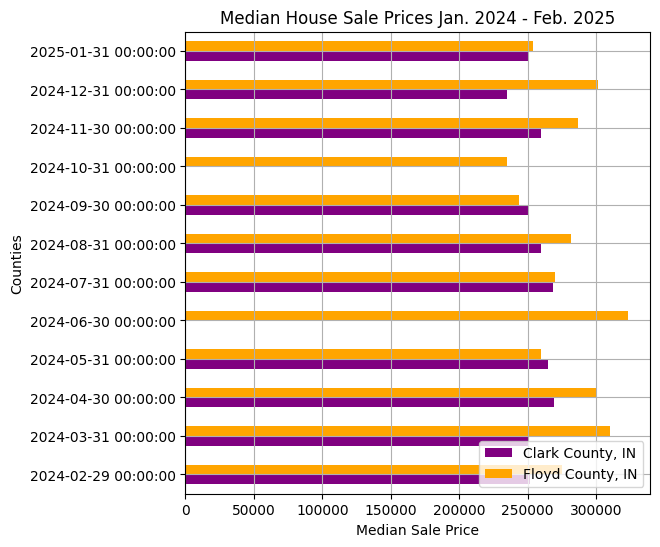

In [205]:
# Pivot the data to have 'Product' as columns and 'Segment' as the index
pivot_df =filtered_cf.pivot(index='Period End',
                    columns='Region',
                    values='Median Sale Price')

# Create a grouped barplot
colors = ['purple', 'orange']
ax = pivot_df.plot.barh(grid=True,
                       color=colors,
                       figsize=(6,6))

# Add legend
plt.legend(loc='lower right')

#Add title and label
ax.set_xlabel('Median Sale Price')
ax.set_ylabel('Counties')
ax.set_title('Median House Sale Prices Jan. 2024 - Feb. 2025')

plt.show()

In [206]:
#display avg. price per square foot df for reference while plotting
average_ppsf

,Median Ppsf
Region,
"Clark County, IN",163.120663
"Floyd County, IN",151.948779


In [207]:
#bar chart showing average Median Ppsf for 
ax = average_ppsf.plot.bar(x='Region', 
                           y='Median Ppsf', 
                           rot=0, 
                           xlabel='County', 
                           ylabel='Price per Square Foot ($)', 
                           title="Average Median Price per Square Foot from Feb. 2024 - Jan. 2025"
                           )

KeyError: 'Region'

In [ ]:
#display avg. sale price df for reference while plotting
average_saleprice

In [ ]:
average Median Ppsf for 
ax1 = average_saleprice.plot.bar(x='Region', 
                                 y='Median Sale Price', 
                                 rot=0, 
                                 xlabel='County', 
                                 ylabel='Average Median Sale Price ($)', 
                                 title="Average Median Sale Price from Feb. 2024 - Jan. 2025"
                                 )

In [ ]:
#displaying dataframe to assist with visualization
merged_ilearnG3df

In [ ]:
#
ilearn_copy = merged_ilearnG3df.copy()

#changing objects to floats
ilearn_copy['ELA Proficient %'] = ilearn_copy['ELA Proficient %'].str.rstrip('%').astype('float') / 100.0
ilearn_copy

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,0.309,49.1%,49.6%
1,0945,Silver Creek School Corporation,0.417,54.8%,41.5%
2,1000,Clarksville Community School Corp,0.137,25.1%,20.6%
3,1010,Greater Clark County Schools,0.353,47.1%,37.6%
4,2400,New Albany-Floyd Co Con Sch,0.558,71.1%,49.1%


In [208]:
#changing objects to floats
ilearn_copy['Math Proficient %'] = ilearn_copy['Math Proficient %'].str.rstrip('%').astype('float') / 100.0
ilearn_copy

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,0.309,0.491,49.6%
1,0945,Silver Creek School Corporation,0.417,0.548,41.5%
2,1000,Clarksville Community School Corp,0.137,0.251,20.6%
3,1010,Greater Clark County Schools,0.353,0.471,37.6%
4,2400,New Albany-Floyd Co Con Sch,0.558,0.711,49.1%


In [209]:
#changing objects to floats
ilearn_copy['Science Proficient %'] = ilearn_copy['Science Proficient %'].str.rstrip('%').astype('float') / 100.0
ilearn_copy

,Corp ID,Corporation Name,ELA Proficient %,Math Proficient %,Science Proficient %
0,0935,Borden-Henryville School Corporation,0.309,0.491,0.496
1,0945,Silver Creek School Corporation,0.417,0.548,0.415
2,1000,Clarksville Community School Corp,0.137,0.251,0.206
3,1010,Greater Clark County Schools,0.353,0.471,0.376
4,2400,New Albany-Floyd Co Con Sch,0.558,0.711,0.491


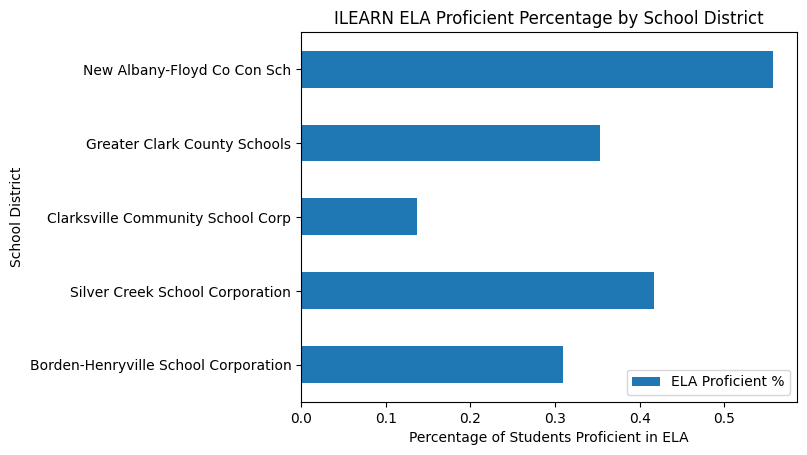

In [210]:
#bar chart to plot % of students proficient in ELA by School District
ax2 = ilearn_copy.plot.barh(x='Corporation Name', 
                                 y='ELA Proficient %', 
                                 rot=0, 
                                 xlabel='Percentage of Students Proficient in ELA', 
                                 ylabel='School District', 
                                 title="ILEARN ELA Proficient Percentage by School District") # look up label rotation


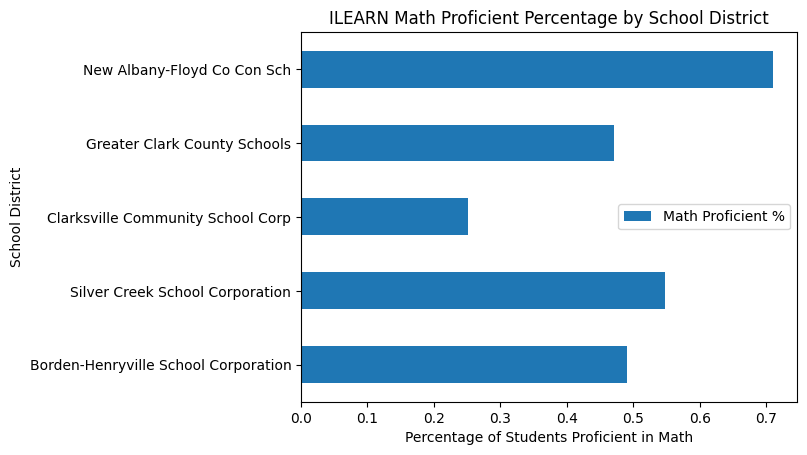

In [211]:
#bar chart to plot % of students proficient in ELA by School District
ax2 = ilearn_copy.plot.barh(x='Corporation Name', 
                                 y='Math Proficient %', 
                                 rot=0, 
                                 xlabel='Percentage of Students Proficient in Math', 
                                 ylabel='School District', 
                                 title="ILEARN Math Proficient Percentage by School District")

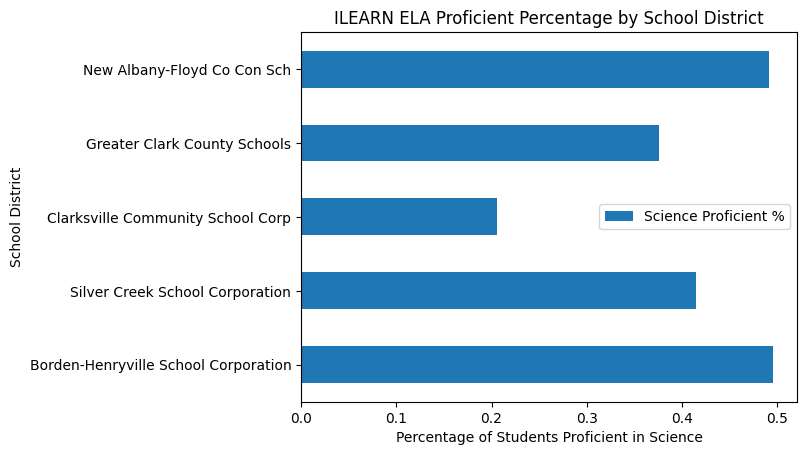

In [212]:
#bar chart to plot % of students proficient in ELA by School District
ax3 = ilearn_copy.plot.barh(x='Corporation Name', 
                                 y='Science Proficient %', 
                                 rot=0, 
                                 xlabel='Percentage of Students Proficient in Science', 
                                 ylabel='School District', 
                                 title="ILEARN ELA Proficient Percentage by School District")

In [213]:
#display Social Studies Proficiency df for reference while plotting
soc_copy3

,Corp ID,Corporation Name,Social Studies Proficient %
24,0935,Borden-Henryville School Corporation,26.4%
25,0945,Silver Creek School Corporation,29.3%
26,1000,Clarksville Community School Corp,14.6%
27,1010,Greater Clark County Schools,28.4%
64,2400,New Albany-Floyd Co Con Sch,40.1%


In [214]:
# change objects to floats
soc_copy3 ['Social Studies Proficient %'] =soc_copy3 ['Social Studies Proficient %'].str.rstrip('%').astype('float') / 100.0

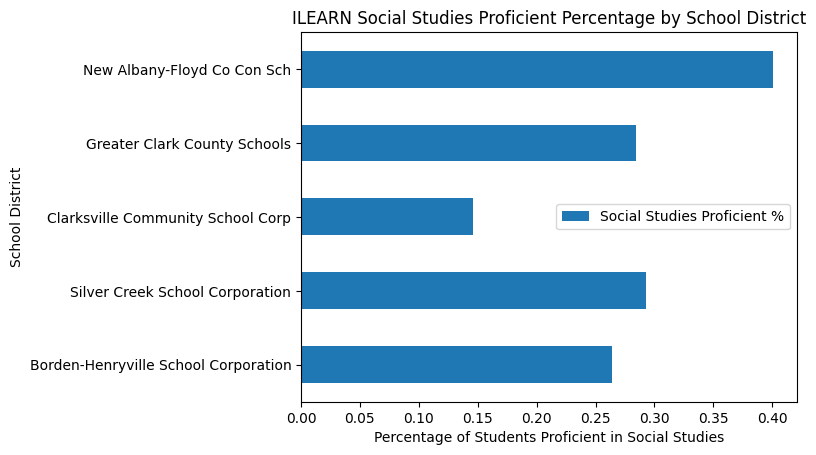

In [216]:
#bar chart to plot % of students proficient in ELA by School District
ax4 = soc_copy3.plot.barh(x='Corporation Name', 
                         y='Social Studies Proficient %', 
                         rot=0, 
                         xlabel='Percentage of Students Proficient in Social Studies', 
                         ylabel='School District', 
                         title="ILEARN Social Studies Proficient Percentage by School District"
                         )